<a href="https://colab.research.google.com/github/LaxmiBandi/Machine_Learning/blob/main/Gradient_boosting_power_prediction%20_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv('/content/test.csv')
df.head()

,ID,datetime,temperature,var1,pressure,windspeed,var2
0,552,2013-07-24 00:00:00,-10.0,-16.4,1011.0,263.280,A
1,553,2013-07-24 01:00:00,-10.0,-20.7,1011.0,267.175,A
2,554,2013-07-24 02:00:00,-10.7,-17.1,1003.0,269.555,A
3,555,2013-07-24 03:00:00,-13.6,-20.7,1008.0,273.060,A
4,556,2013-07-24 04:00:00,-10.7,-17.1,1006.0,1.765,A


In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df = df.dropna()

In [5]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [6]:
target = 'var1'  # demand
features = ['temperature', 'pressure', 'windspeed', 'hour', 'day', 'month']

X = df[features]
y = df[target]

In [7]:
split = int(0.8 * len(df))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

model.fit(X_train, y_train)

GradientBoostingRegressor()

In [9]:
predictions = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.1265946531949584
RMSE: 3.9633111229022835


In [11]:
iso = IsolationForest(contamination=0.02)

df['anomaly'] = iso.fit_predict(df[[target]])

df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

In [12]:
def risk_level(x):
    return "HIGH" if x == -1 else "LOW"

df['risk'] = df['anomaly'].apply(risk_level)

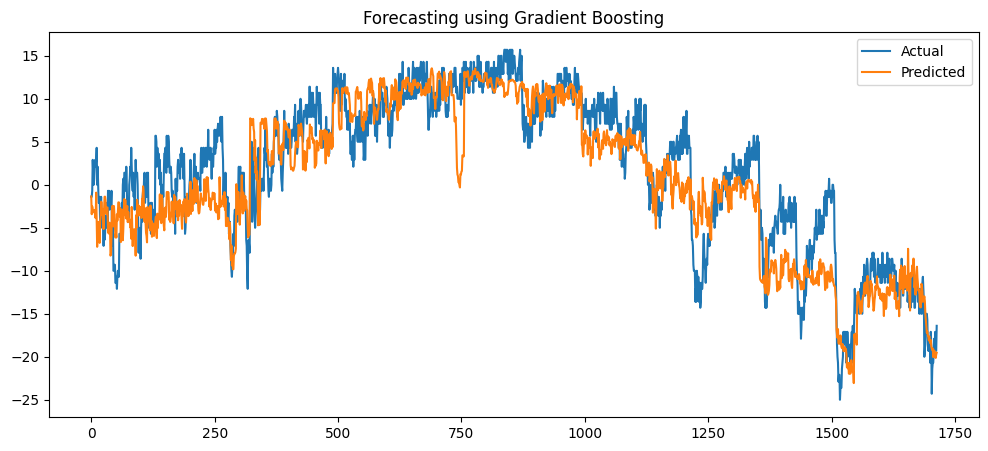

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Forecasting using Gradient Boosting")
plt.show()

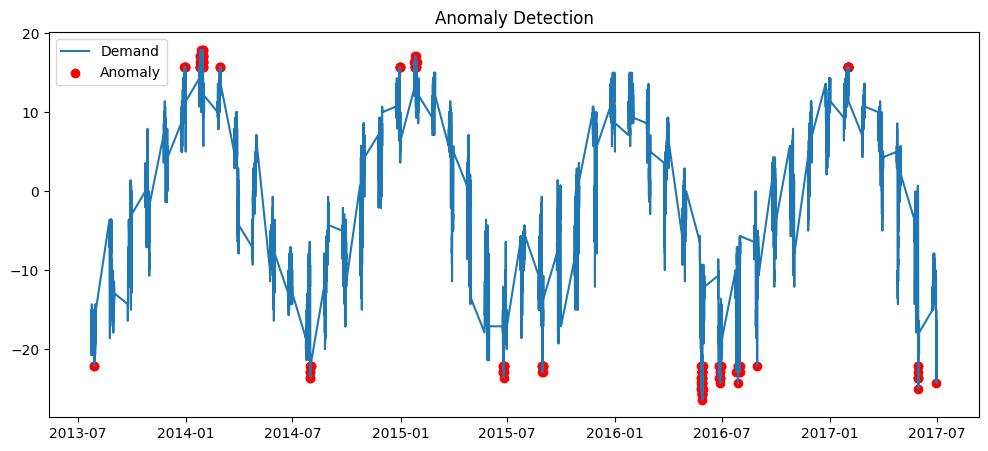

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['datetime'], df[target], label='Demand')

anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies['datetime'], anomalies[target], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [15]:
print(df[['datetime', target, 'anomaly_label', 'risk']].head(10))

             datetime  var1 anomaly_label risk
0 2013-07-24 00:00:00 -16.4        Normal  LOW
1 2013-07-24 01:00:00 -20.7        Normal  LOW
2 2013-07-24 02:00:00 -17.1        Normal  LOW
3 2013-07-24 03:00:00 -20.7        Normal  LOW
4 2013-07-24 04:00:00 -17.1        Normal  LOW
5 2013-07-24 05:00:00 -20.0        Normal  LOW
6 2013-07-24 06:00:00 -20.7        Normal  LOW
7 2013-07-24 07:00:00 -17.9        Normal  LOW
8 2013-07-24 08:00:00 -17.1        Normal  LOW
9 2013-07-24 09:00:00 -19.3        Normal  LOW


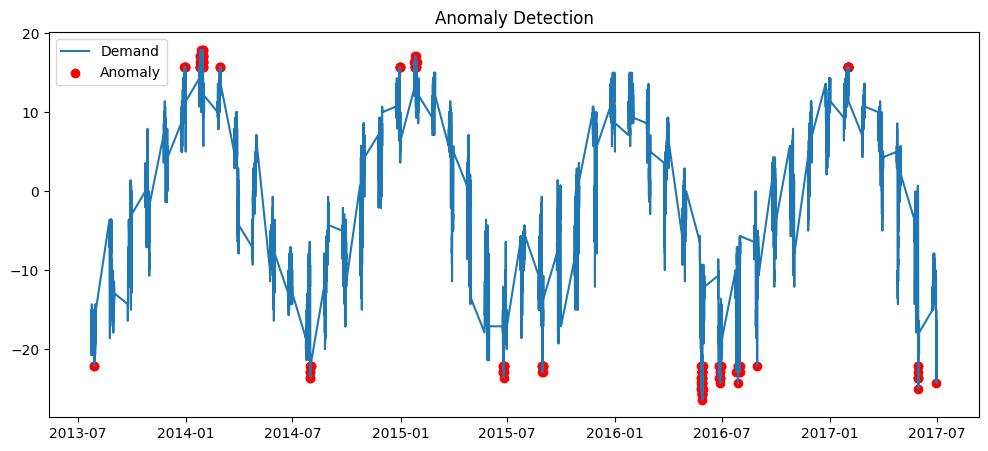

In [18]:
plt.figure(figsize=(12,5))
plt.plot(df['datetime'], df[target], label='Demand')

anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies['datetime'], anomalies[target], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error

print("Final MAE:", mean_absolute_error(y_test, predictions))

Final MAE: 3.1265946531949584


In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear MAE:", mean_absolute_error(y_test, lr_pred))
print("Boosting MAE:", mean_absolute_error(y_test, predictions))

Linear MAE: 3.9852712607084095
Boosting MAE: 3.1265946531949584


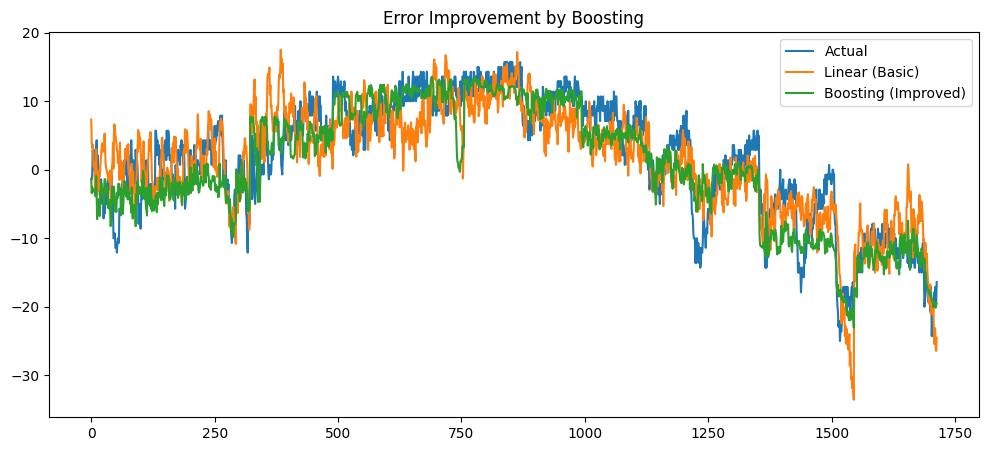

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')
plt.plot(lr_pred, label='Linear (Basic)')
plt.plot(predictions, label='Boosting (Improved)')

plt.legend()
plt.title("Error Improvement by Boosting")
plt.show()

In [22]:
import pandas as pd

importance = model.feature_importances_

for f, i in zip(features, importance):
    print(f, i)

temperature 0.6262621494003021
pressure 0.04201181154783437
windspeed 0.05362583056836955
hour 0.005357237778946361
day 0.005384214232602878
month 0.2673587564719447


In [35]:
model = GradientBoostingRegressor(n_estimators=100)

In [39]:
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [41]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

model = GradientBoostingRegressor()

# Fit model
model.fit(X_train, y_train)

# Check staged predictions
for i, pred in enumerate(model.staged_predict(X_test)):
    if i % 20 == 0:
        mae = mean_absolute_error(y_test, pred)
        print(f"Step {i} MAE:", mae)

Step 0 MAE: 7.749982019587466
Step 20 MAE: 3.490726386722103
Step 40 MAE: 3.1604104461616873
Step 60 MAE: 3.1162528478155784
Step 80 MAE: 3.1195506494132332
